# Stage 1 — Foundation Models across Time Granularities (Monash Energy)

**Goal.** See how three pretrained time-series foundation models — **Chronos** (Amazon),
**TimesFM** (Google) and **Moirai** (Salesforce) — behave on Monash **energy** series at
different temporal resolutions (**minutes → hours → day**), and **compare the three
models** against each other. **No baselines** — this is purely about the foundation models.

**Method.** For each energy type (electricity demand, solar, wind) we take one
high-resolution Monash series and **resample it** to each granularity. Feeding the *same*
underlying signal at different resolutions means any accuracy difference is due to
granularity — not to a different dataset. Each model forecasts **zero-shot**; we score with
MASE, sMAPE, RMSE, MAE and inference time, then compare the models per granularity and per
energy type.

> **Runtime.** A GPU makes this much faster but is **not required** — the code auto-detects
> CUDA and falls back to CPU (slower, but fine for the small default batch).
>
> **Running in VS Code / local Jupyter.** This notebook runs as-is. Notes:
> the `#@param ... { display-mode: "form" }` comments are Colab-only — in VS Code they
> render as ordinary comments and the variables still take their assigned values (edit them
> directly). Before running, create an environment and select it as the kernel
> (see the `requirements.txt` / setup steps shipped alongside this notebook). The `%pip
> install` cells work inside a Jupyter kernel; if you prefer, install from `requirements.txt`
> in a terminal instead and skip the install cells.


## 1. Install & check runtime

In [ ]:
#@title Install dependencies (Chronos + TimesFM + Moirai)
# NOTE: if you already installed everything into your .venv from a terminal
# (the normal way when running in VS Code), SKIP this cell — start at "GPU check".
# The `2>/dev/null` redirect that used to be here is Linux/Colab-only: on Windows
# there is no /dev/null path, which is what produced the repeated
# "The system cannot find the path specified." messages. It has been removed.
INSTALL_CHRONOS = False   # set True only if the import below fails
INSTALL_TIMESFM = False
INSTALL_MOIRAI  = False

if INSTALL_CHRONOS:
    %pip install -q chronos-forecasting
if INSTALL_TIMESFM:
    %pip install -q "timesfm[torch]"
if INSTALL_MOIRAI:
    %pip install -q uni2ts "datasets==2.17.1"
print("Install cell finished (all flags False = nothing installed, which is correct "
      "if your .venv is already set up).")


In [3]:
#@title GPU check
import torch
print("PyTorch:", torch.__version__)
print("GPU    :", torch.cuda.get_device_name(0) if torch.cuda.is_available()
      else "NONE — enable GPU for reasonable speed.")


PyTorch: 2.5.1+cu121
GPU    : NVIDIA GeForce RTX 3060 Laptop GPU


## 2. Configuration

A small batch keeps the whole comparison quick; raise `SERIES_PER_TYPE` once it runs.
The granularity ladder is **minutes (native) → hourly → daily**.


In [1]:
#@title Config
import numpy as np
np.random.seed(7)

# One base Monash series per energy type (native = finest resolution), then resample.
BASE = {
    "load":  {"config": "australian_electricity_demand", "native_freq": "30min", "label": "AU Electricity Demand"},
    "solar": {"config": "solar_10_minutes",              "native_freq": "10min", "label": "Solar Generation"},
    "wind":  {"config": "wind_farms_minutely",           "native_freq": "1min",  "label": "Wind Generation"},
}

# Granularity ladder: minutes / hours / day. (pandas offset alias, seasonal m, horizon steps)
GRANULARITIES = {
    "native": {"label": "minutes (native)", "resample": None, "m": None, "horizon": 48},
    "1h":     {"label": "hourly",           "resample": "1h", "m": 24,  "horizon": 24},
    "1D":     {"label": "daily",            "resample": "1D", "m": 7,   "horizon": 14},
}
NATIVE_M = {"load": 48, "solar": 144, "wind": 1440}   # steps/day at native resolution (for MASE)

SERIES_PER_TYPE = 3      # small batch
N_TEST_WINDOWS  = 2      # rolling-origin windows per (series, granularity)
CONTEXT_LENGTH  = 512    # history length fed to each model
RANDOM_SEED     = 7
RESAMPLE_AGG    = "mean" # average power when coarsening (use 'sum' for energy totals)

RUN_MODELS = {"chronos": True, "timesfm": True, "moirai": True}
CHRONOS_MODEL = "amazon/chronos-bolt-small"
# TimesFM: the pip package changed API. timesfm>=2.x exposes TimesFM_2p5_*_torch
# and only loads 2.5 checkpoints; timesfm 1.x exposes TimesFm + TimesFmHparams and
# loads the 2.0 checkpoint. The wrapper in section 5 detects which one you have.
TIMESFM_REPO        = "google/timesfm-2.5-200m-pytorch"   # used by timesfm >= 2.x
TIMESFM_REPO_LEGACY = "google/timesfm-2.0-500m-pytorch"   # used by timesfm 1.x
MOIRAI_REPO   = "Salesforce/moirai-1.1-R-small"
RESULTS_PATH  = "stage1_granularity_results.parquet"

print("Types      :", list(BASE))
print("Granularity:", [g["label"] for g in GRANULARITIES.values()])
print("Models     :", [k for k,v in RUN_MODELS.items() if v])


Types      : ['load', 'solar', 'wind']
Granularity: ['minutes (native)', 'hourly', 'daily']
Models     : ['chronos', 'timesfm', 'moirai']


## 3. Load a small batch of Monash energy series

In [2]:
from datasets import load_dataset
import pandas as pd

def load_monash(config):
    ds = load_dataset("Monash-University/monash_tsf", config, trust_remote_code=True)
    split = "test" if "test" in ds else list(ds.keys())[0]
    out = []
    for row in ds[split]:
        arr = np.asarray(row["target"], float); arr = arr[np.isfinite(arr)]
        if arr.size: out.append({"target": arr, "start": row.get("start", None)})
    return out

def to_series(entry, freq):
    try:
        idx = pd.date_range(pd.Timestamp(entry["start"]), periods=len(entry["target"]), freq=freq)
    except Exception:
        idx = pd.date_range("2015-01-01", periods=len(entry["target"]), freq=freq)
    return pd.Series(entry["target"], index=idx)

min_native = CONTEXT_LENGTH + GRANULARITIES["native"]["horizon"] * N_TEST_WINDOWS
DATA = {}
for et, info in BASE.items():
    print(f"Loading {info['config']} ({et}) ...", end=" ", flush=True)
    raw = load_monash(info["config"])
    elig = [e for e in raw if e["target"].size >= min_native] or sorted(raw, key=lambda e:-e["target"].size)
    rng = np.random.default_rng(RANDOM_SEED)
    pick = [elig[i] for i in rng.permutation(len(elig))[:SERIES_PER_TYPE]]
    DATA[et] = [to_series(e, info["native_freq"]) for e in pick]
    print(f"{len(raw)} series -> using {len(DATA[et])}")


e:\Thesis\EnergyForcastModel\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading australian_electricity_demand (load) ... 5 series -> using 3
Loading solar_10_minutes (solar) ... 137 series -> using 3
Loading wind_farms_minutely (wind) ... 339 series -> using 3


In [3]:
# First rows of all sampled load series side by side
load_df = pd.concat({f"series_{i}": s for i, s in enumerate(DATA["load"])}, axis=1)
display(load_df.head(10))

,series_0,series_1,series_2
2002-01-01 00:00:00,3382.041260,5714.044922,315.915497
2002-01-01 00:30:00,3288.315674,5360.188965,306.245850
2002-01-01 01:00:00,3172.329102,5014.834961,305.762573
2002-01-01 01:30:00,3020.312988,4602.755371,295.602203
2002-01-01 02:00:00,2918.082764,4285.179688,290.447083
2002-01-01 02:30:00,2839.923828,4074.894531,282.577576
2002-01-01 03:00:00,2810.689209,3942.936035,277.692078
2002-01-01 03:30:00,2768.326660,3883.997559,275.753876
2002-01-01 04:00:00,2738.259033,3877.679932,278.291840
2002-01-01 04:30:00,2727.975586,3837.716553,272.943848


## 4. Resample, cut evaluation windows, define metrics

MASE's denominator is a seasonal-naïve scale on the context — used **only** as a
normaliser so errors are comparable across granularities, not as a baseline model.


In [4]:
from dataclasses import dataclass

def resample_series(s, rule, agg="mean"):
    if rule is None: return s
    r = s.resample(rule); return (r.mean() if agg=="mean" else r.sum()).dropna()

@dataclass
class Window:
    etype:str; series_id:int; gran:str; horizon:int
    context:np.ndarray; truth:np.ndarray; m:int

def build_windows(data):
    W=[]
    for et, series_list in data.items():
        for sid, sn in enumerate(series_list):
            for gk, g in GRANULARITIES.items():
                vals = resample_series(sn, g["resample"], RESAMPLE_AGG).values.astype(float)
                h = g["horizon"]; m = g["m"] if g["m"] is not None else NATIVE_M[et]
                for w in range(N_TEST_WINDOWS):
                    end = len(vals)-w*h; st = end-h
                    ctx = min(CONTEXT_LENGTH, st)              # adaptive: fit short coarse series
                    if ctx < max(2*h, 16): continue
                    sc = st-ctx
                    W.append(Window(et, sid, gk, h, vals[sc:st].copy(),
                                    vals[st:end].copy(), min(m, ctx-1)))
    return W

WINDOWS = build_windows(DATA)
from collections import Counter
print(len(WINDOWS), "windows |", dict(Counter(w.gran for w in WINDOWS)))


54 windows | {'native': 18, '1h': 18, '1D': 18}


In [5]:
def _scale(ctx, m):
    if ctx.size <= m: m = 1
    d = np.abs(ctx[m:]-ctx[:-m]); s = d.mean() if d.size else 1.0
    return s if s>1e-8 else 1.0

def metrics(truth, pred, ctx, m):
    truth=np.asarray(truth,float); pred=np.asarray(pred,float); e=pred-truth
    mae=np.mean(np.abs(e)); rmse=np.sqrt(np.mean(e**2))
    den=np.abs(truth)+np.abs(pred); safe=np.where(den==0,1.0,den)
    smape=np.mean(np.where(den==0,0.0,2*np.abs(e)/safe))*100
    return {"MAE":mae,"RMSE":rmse,"sMAPE":smape,"MASE":mae/_scale(ctx,m)}

_t=np.array([1.,2.,3.]); _c=np.arange(50.0)
assert metrics(_t,_t,_c,1)["MAE"]==0 and metrics(_t,_t+1,_c,1)["MAE"]==1.0
print("metrics OK")


metrics OK


## 5. The three foundation models (uniform interface)

Each model exposes `predict(context, horizon) -> point forecast`; weights load once.

> **Fixed here (this was the cause of the all-NaN metrics).**
>
> 1. **Chronos** — `chronos-forecasting` **2.x renamed the first argument of
>    `predict_quantiles` from `context` to `inputs`**. The old call
>    `predict_quantiles(context=ctx, ...)` therefore sent `ctx` into `**kwargs` and raised
>    `TypeError: predict_quantiles() missing 1 required positional argument: 'inputs'`
>    on *every* window — instantly, before any GPU work (hence `infer_sec` ≈ 0.0005 s).
>    The evaluation loop swallowed that exception and wrote `NaN`. It is now passed
>    **positionally**, which is correct on both 1.x and 2.x.
> 2. **TimesFM** — `timesfm` 2.x removed `timesfm.TimesFm` / `TimesFmHparams`
>    (`AttributeError: module 'timesfm' has no attribute 'TimesFm'`). The wrapper now
>    detects the installed API and uses the modern `TimesFM_2p5_200M_torch` +
>    `ForecastConfig` path, falling back to the 1.x path (with the **correct 500M
>    hyper-parameters**, which were also missing before) if you have `timesfm==1.3.0`.
> 3. **Moirai** — was rebuilding and re-uploading the forecaster to the GPU on every
>    window (≈2.9 s/window). It is now cached per `(horizon, context_length)`.


In [6]:
from abc import ABC, abstractmethod
import numpy as np, torch

class FM(ABC):
    name="fm"
    @abstractmethod
    def predict(self, context, horizon): ...
    def warmup(self): return self
    def free(self):
        """Release GPU memory held by this model (important on small VRAM)."""
        import gc
        for a in ("pipe","model","module"):
            if getattr(self, a, None) is not None: setattr(self, a, None)
        if getattr(self, "_cache", None): self._cache.clear()
        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

# ----------------------------------------------------------------- Chronos (FIXED)
class ChronosFM(FM):
    """chronos-forecasting >= 2.0 renamed predict_quantiles(context=...) -> (inputs=...).
    We pass the series POSITIONALLY, which is valid on both 1.x and 2.x."""
    name="chronos"
    def __init__(self): self.pipe=None
    def warmup(self):
        from chronos import BaseChronosPipeline
        dev="cuda" if torch.cuda.is_available() else "cpu"
        dt=torch.bfloat16 if dev=="cuda" else torch.float32
        try:
            self.pipe=BaseChronosPipeline.from_pretrained(CHRONOS_MODEL, device_map=dev,
                                                          torch_dtype=dt)
        except TypeError:      # transformers >= 5 renamed torch_dtype -> dtype
            self.pipe=BaseChronosPipeline.from_pretrained(CHRONOS_MODEL, device_map=dev,
                                                          dtype=dt)
        return self
    def predict(self, context, horizon):
        if self.pipe is None: self.warmup()
        ctx=torch.tensor(np.asarray(context[-CONTEXT_LENGTH:], dtype=float),
                         dtype=torch.float32)
        q,_=self.pipe.predict_quantiles(ctx,                      # <-- positional (the fix)
                                        prediction_length=horizon,
                                        quantile_levels=[0.1,0.5,0.9])
        # q: (batch, prediction_length, n_quantiles) -> column 1 is the 0.5 quantile.
        # .float() guards against bf16, which numpy cannot convert.
        return q[0,:,1].float().cpu().numpy().astype(float)

# ----------------------------------------------------------------- TimesFM (FIXED)
class TimesFMFM(FM):
    """Handles BOTH pip APIs:
       timesfm >= 2.x : timesfm.TimesFM_2p5_200M_torch + ForecastConfig  (2.5 checkpoints)
       timesfm 1.x    : timesfm.TimesFm + TimesFmHparams/TimesFmCheckpoint (2.0 checkpoint)
    The 1.x branch now passes the 500M architecture hyper-parameters, which are
    REQUIRED for google/timesfm-2.0-500m-pytorch and were missing before."""
    name="timesfm"
    def __init__(self): self.model=None; self._api=None
    def warmup(self):
        import timesfm
        self._h  =max(g["horizon"] for g in GRANULARITIES.values())
        self._ctx=(CONTEXT_LENGTH//32)*32
        if hasattr(timesfm, "TimesFM_2p5_200M_torch"):                 # ---- modern API
            self._api="2p5"
            self.model=timesfm.TimesFM_2p5_200M_torch.from_pretrained(TIMESFM_REPO)
            try:
                self.model.compile(timesfm.ForecastConfig(
                    max_context=self._ctx, max_horizon=self._h,
                    normalize_inputs=True, use_continuous_quantile_head=True,
                    force_flip_invariance=True, infer_is_positive=True,
                    fix_quantile_crossing=True))
            except Exception:                                          # minimal fallback
                self.model.compile(timesfm.ForecastConfig(
                    max_context=self._ctx, max_horizon=self._h, normalize_inputs=True))
        elif hasattr(timesfm, "TimesFm"):                              # ---- legacy API
            self._api="1x"
            backend="gpu" if torch.cuda.is_available() else "cpu"
            self.model=timesfm.TimesFm(
                hparams=timesfm.TimesFmHparams(
                    backend=backend, per_core_batch_size=16,
                    horizon_len=self._h, context_len=self._ctx,
                    # fixed architecture of the 500M checkpoint:
                    input_patch_len=32, output_patch_len=128,
                    num_layers=50, model_dims=1280, use_positional_embedding=False),
                checkpoint=timesfm.TimesFmCheckpoint(
                    huggingface_repo_id=TIMESFM_REPO_LEGACY))
        else:
            raise ImportError(
                "Unrecognised timesfm API: neither TimesFM_2p5_200M_torch nor TimesFm "
                "found. Install one of:  pip install 'timesfm[torch]'  (>=2.x)  or "
                "pip install 'timesfm[torch]==1.3.0'  (legacy).")
        print(f"    timesfm API = {self._api}")
        return self
    def predict(self, context, horizon):
        if self.model is None: self.warmup()
        x=np.asarray(context[-self._ctx:], dtype=float)
        if self._api=="2p5":
            pt,_=self.model.forecast(horizon=max(horizon, 1), inputs=[x])
        else:
            pt,_=self.model.forecast([x], freq=[0])
        return np.asarray(pt[0][:horizon], dtype=float)

# ----------------------------------------------------------------- Moirai (cached)
class MoiraiFM(FM):
    name="moirai"
    def __init__(self,num_samples=100,patch_size=32):
        self.ns=num_samples; self.ps=patch_size; self.module=None; self._cache={}
    def warmup(self):
        from uni2ts.model.moirai import MoiraiModule
        self.module=MoiraiModule.from_pretrained(MOIRAI_REPO); return self
    def _forecaster(self, horizon, ctx_len):
        from uni2ts.model.moirai import MoiraiForecast
        key=(horizon, ctx_len)
        if key not in self._cache:                # build once per (horizon, context) pair
            m=MoiraiForecast(module=self.module, prediction_length=horizon,
                             context_length=ctx_len, patch_size=self.ps,
                             num_samples=self.ns, target_dim=1,
                             feat_dynamic_real_dim=0, past_feat_dynamic_real_dim=0)
            dev="cuda" if torch.cuda.is_available() else "cpu"
            self._cache[key]=m.to(dev).eval()
        return self._cache[key]
    def predict(self, context, horizon):
        if self.module is None: self.warmup()
        ctx=np.asarray(context[-CONTEXT_LENGTH:], dtype=float)
        model=self._forecaster(horizon, len(ctx))
        dev="cuda" if torch.cuda.is_available() else "cpu"
        pt =torch.tensor(ctx,dtype=torch.float32,device=dev).reshape(1,-1,1)
        obs=torch.ones_like(pt,dtype=torch.bool)
        pad=torch.zeros(1,pt.shape[1],dtype=torch.bool,device=dev)
        with torch.no_grad():
            fc=model(past_target=pt, past_observed_target=obs, past_is_pad=pad)
        return np.median(fc[0].cpu().numpy(),axis=0)[:horizon].astype(float)

FM_CLASSES={"chronos":ChronosFM,"timesfm":TimesFMFM,"moirai":MoiraiFM}
# Instantiate (but DON'T load weights yet). On a 6 GB GPU we load one model at a
# time in the evaluation loop and free its VRAM before the next.
MODELS={k:FM_CLASSES[k]() for k,on in RUN_MODELS.items() if on}
print("models to run (loaded lazily, one at a time):", list(MODELS))


models to run (loaded lazily, one at a time): ['chronos', 'timesfm', 'moirai']


### 5b. Smoke test — one window per model, errors shown in full

**Run this before the full loop.** It calls each model exactly once *outside* any
`try/except`-to-NaN logic, so a broken wrapper shows a real traceback instead of silently
turning into `NaN` 54 times. Each model is freed from VRAM before the next loads.


In [7]:
import traceback
w = WINDOWS[0]
print(f"test window: {w.etype} @ {w.gran} | context={len(w.context)} | horizon={w.horizon}\n")
for name, model in MODELS.items():
    try:
        p = np.asarray(model.predict(w.context, w.horizon), dtype=float)
        good = (p.shape[0] >= w.horizon) and np.all(np.isfinite(p[:w.horizon]))
        print(f"{name:8s} {'OK  ' if good else 'BAD '} shape={p.shape} "
              f"finite={np.all(np.isfinite(p))} first3={np.round(p[:3],2)}")
        if good:
            mt = metrics(w.truth, p[:w.horizon], w.context, w.m)
            print(f"{'':8s}      " + "  ".join(f"{k}={v:.3f}" for k, v in mt.items()))
    except Exception:
        print(f"{name:8s} FAILED")
        traceback.print_exc()
    finally:
        model.free()
    print("-" * 74)


test window: load @ native | context=512 | horizon=48

chronos  OK   shape=(48,) finite=True first3=[3904. 3760. 3664.]
              MAE=203.118  RMSE=261.051  sMAPE=3.953  MASE=0.636
--------------------------------------------------------------------------
    timesfm API = 2p5
timesfm  OK   shape=(48,) finite=True first3=[3918.11 3781.02 3658.75]
              MAE=75.141  RMSE=99.903  sMAPE=1.556  MASE=0.235
--------------------------------------------------------------------------
moirai   OK   shape=(48,) finite=True first3=[4155.58 4018.17 3872.35]
              MAE=316.205  RMSE=396.719  sMAPE=6.193  MASE=0.990
--------------------------------------------------------------------------


## 6. Run the models across all granularities

**Memory-safe for 6 GB GPUs.** Models are evaluated **one at a time**: each is loaded, run
over every window, then its GPU memory is freed before the next model loads.

**Errors are no longer silent.** Previously any exception inside `predict()` was caught and
written as `NaN`, so a broken call looked like "the model produced nothing" instead of
"the code crashed". The loop now records the error text per window, prints the **first full
traceback per model**, and reports a **NaN rate** at the end — if a model fails, you see why
immediately.


In [8]:
import time, os, traceback
import pandas as pd
from tqdm.auto import tqdm

# Reduce fragmentation OOM on small GPUs (harmless elsewhere).
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

def gpu_mem():
    if torch.cuda.is_available():
        return f"{torch.cuda.memory_allocated()/1e9:.2f} GB used"
    return "CPU"

rows=[]; first_tb={}
for name, model in MODELS.items():
    try:
        print(f"loading {name} ...", flush=True); model.warmup()
    except Exception:
        print(f"  SKIPPED {name} — could not load:"); traceback.print_exc(); continue
    n_ok=0
    for w in tqdm(WINDOWS, desc=name):
        t0=time.perf_counter(); err=""
        try:
            p=np.asarray(model.predict(w.context, w.horizon), dtype=float)
            if p.shape[0] < w.horizon:
                raise ValueError(f"forecast too short: {p.shape[0]} < horizon {w.horizon}")
            p=p[:w.horizon]
            if not np.all(np.isfinite(p)):
                raise ValueError("forecast contains NaN/inf")
            met=metrics(w.truth, p, w.context, w.m); n_ok+=1
        except Exception as e:
            met={"MAE":np.nan,"RMSE":np.nan,"sMAPE":np.nan,"MASE":np.nan}
            err=f"{type(e).__name__}: {e}"
            first_tb.setdefault(name, traceback.format_exc())
        dt=time.perf_counter()-t0
        rows.append({"etype":w.etype,"gran":w.gran,
                     "gran_label":GRANULARITIES[w.gran]["label"],
                     "series_id":w.series_id,"horizon":w.horizon,"model":name,
                     "infer_sec":dt,"error":err,**met})
    print(f"  {name}: {n_ok}/{len(WINDOWS)} windows scored | {gpu_mem()} -> freeing")
    model.free()

# --- surface the real reason for any failure (this is what was hidden before) -------
for name, tb in first_tb.items():
    print("="*78); print(f"FIRST ERROR for {name}:"); print(tb)

res=pd.DataFrame(rows)
if res.empty:
    raise RuntimeError("No results at all — every model failed to load. See tracebacks above.")
res.to_parquet(RESULTS_PATH, index=False)
print(len(res), "rows saved ->", RESULTS_PATH)

nan_rate=res.groupby("model")["MASE"].apply(lambda s: float(s.isna().mean()))
print("\nNaN rate per model:")
for k,v in nan_rate.items(): print(f"  {k:8s} {v:6.1%}")
if (nan_rate > 0).any():
    print("\n!! Some windows produced no score — read the traceback(s) above before "
          "trusting section 7.")
else:
    print("\nAll windows scored — results are valid.")
res.head()


loading chronos ...


chronos: 100%|██████████| 54/54 [00:04<00:00, 12.44it/s]


  chronos: 54/54 windows scored | 0.10 GB used -> freeing
loading timesfm ...
    timesfm API = 2p5


timesfm: 100%|██████████| 54/54 [00:42<00:00,  1.26it/s]


  timesfm: 54/54 windows scored | 0.93 GB used -> freeing
loading moirai ...


moirai: 100%|██████████| 54/54 [00:08<00:00,  6.38it/s]


  moirai: 54/54 windows scored | 0.06 GB used -> freeing
162 rows saved -> stage1_granularity_results.parquet

NaN rate per model:
  chronos    0.0%
  moirai     0.0%
  timesfm    0.0%

All windows scored — results are valid.


,etype,gran,gran_label,series_id,horizon,model,infer_sec,error,MAE,RMSE,sMAPE,MASE
0,load,native,minutes (native),0,48,chronos,0.126750,,203.118434,261.051179,3.953053,0.636132
1,load,native,minutes (native),0,48,chronos,0.041774,,298.261627,390.923452,5.693729,0.745051
2,load,1h,hourly,0,24,chronos,0.039486,,84.747645,107.564628,1.781022,0.255810
3,load,1h,hourly,0,24,chronos,0.033972,,125.767883,155.575723,2.511832,0.375814
4,load,1D,daily,0,14,chronos,0.035864,,302.123887,376.185119,6.252284,1.244408


## 7. Compare the three models

### 7.1 Accuracy by granularity (per model)
Mean MASE at each granularity — the core "how do they behave across minutes/hours/day" table.


In [9]:
# Guard: drop failed windows so the tables cannot silently average NaNs.
scored = res.dropna(subset=["MASE"])
if scored.empty:
    raise RuntimeError("Every window is NaN — fix the errors printed in section 6 first.")
if len(scored) < len(res):
    print(f"note: using {len(scored)}/{len(res)} scored windows "
          f"({len(res)-len(scored)} failed).")

gran_order=[GRANULARITIES[k]["label"] for k in GRANULARITIES]
t=scored.pivot_table(index="gran_label",columns="model",values="MASE",
                     aggfunc="mean").reindex(gran_order)
t.style.format("{:.3f}").set_caption("Mean MASE by granularity (lower = better)")


model,chronos,moirai,timesfm
gran_label,,,
minutes (native),1.409,1.348,0.992
hourly,1.074,1.350,1.165
daily,1.002,1.063,0.725


### 7.2 Overall model ranking

In [10]:
overall=(scored.groupby("model")[["MASE","sMAPE","RMSE","MAE","infer_sec"]]
         .mean().sort_values("MASE"))
print("Best overall (mean MASE):", overall.index[0] if len(overall) else None)
overall.style.format("{:.3f}").background_gradient(cmap="RdYlGn_r",subset=["MASE","sMAPE"])


Best overall (mean MASE): timesfm


,MASE,sMAPE,RMSE,MAE,infer_sec
model,,,,,
timesfm,0.961,51.184,55.320,43.266,0.791
chronos,1.162,68.556,72.419,58.083,0.079
moirai,1.254,73.371,105.232,85.933,0.154


### 7.3 Best model per energy type × granularity
Shows whether the winner changes with resolution / series type.


In [11]:
if scored["model"].nunique()>1:
    g=scored.groupby(["etype","gran_label","model"])["MASE"].mean().reset_index()
    best=g.loc[g.groupby(["etype","gran_label"])["MASE"].idxmin()]
    display(best.pivot(index="etype",columns="gran_label",values="model")
            .reindex(columns=gran_order).style.set_caption("Best (lowest-MASE) model"))
    key=["etype","gran","series_id","horizon"]
    wide=scored.pivot_table(index=key,columns="model",values="MASE")
    wr=wide.idxmin(axis=1).value_counts(normalize=True).rename("win_rate")
    display(wr.to_frame().style.format("{:.1%}").set_caption("Win-rate (fraction of windows a model is best)"))
else:
    print("Only one model active — enable all three in RUN_MODELS for the comparison.")


gran_label,minutes (native),hourly,daily
etype,,,
load,timesfm,chronos,timesfm
solar,moirai,moirai,moirai
wind,timesfm,chronos,timesfm


,win_rate
timesfm,66.7%
moirai,22.2%
chronos,11.1%


### 7.4 Visual: MASE vs granularity, per energy type

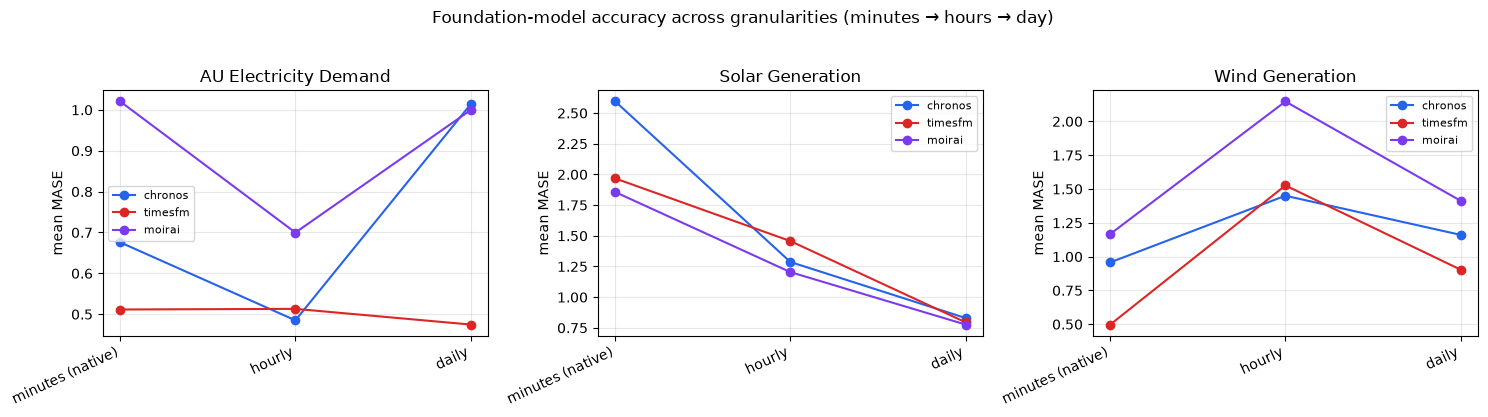

In [12]:
import matplotlib.pyplot as plt
palette={"chronos":"#2563eb","timesfm":"#dc2626","moirai":"#7c3aed"}
types=list(DATA.keys())
fig,axes=plt.subplots(1,len(types),figsize=(5*len(types),4),squeeze=False)
for ax,et in zip(axes[0],types):
    sub=scored[scored.etype==et]
    for mdl in sub.model.unique():
        gg=sub[sub.model==mdl].groupby("gran_label")["MASE"].mean().reindex(gran_order)
        ax.plot(range(len(gg)),gg.values,marker="o",label=mdl,color=palette.get(mdl))
    ax.set_xticks(range(len(gran_order))); ax.set_xticklabels(gran_order,rotation=25,ha="right")
    ax.set_title(BASE[et]["label"]); ax.set_ylabel("mean MASE"); ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.suptitle("Foundation-model accuracy across granularities (minutes → hours → day)",y=1.03)
plt.tight_layout(); plt.show()


### 7.5 Visual: overall MASE per model (bar)

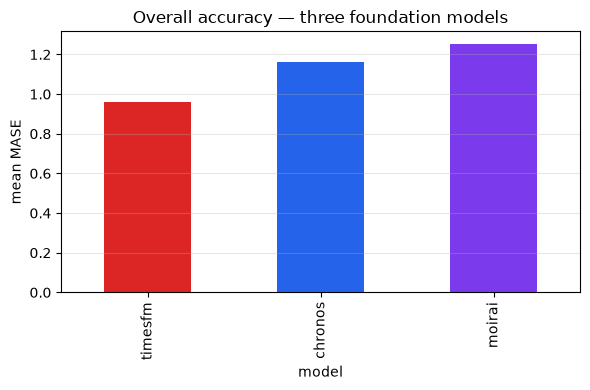

In [13]:
ax=overall["MASE"].plot(kind="bar",figsize=(6,4),color=[palette.get(m,"#333") for m in overall.index])
ax.set_ylabel("mean MASE"); ax.set_title("Overall accuracy — three foundation models")
ax.grid(alpha=.3,axis="y"); plt.tight_layout(); plt.show()


### 7.6 One qualitative forecast (example window)

    timesfm API = 2p5


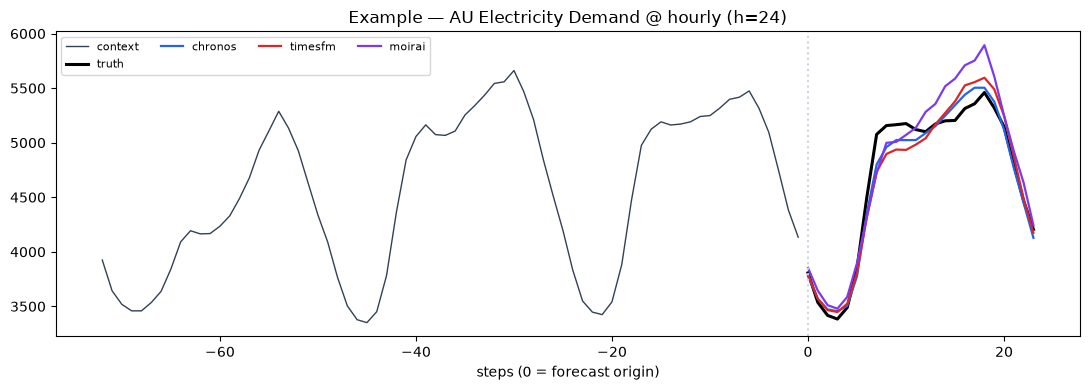

In [14]:
ex=next((w for w in WINDOWS if w.gran=="1h"), WINDOWS[0])
fig,ax=plt.subplots(figsize=(11,4))
hist=ex.context[-3*ex.horizon:]
ax.plot(range(-len(hist),0),hist,color="#334155",lw=1,label="context")
ax.plot(range(0,ex.horizon),ex.truth,color="black",lw=2.2,label="truth")
for name,m in MODELS.items():
    try: ax.plot(range(0,ex.horizon),m.predict(ex.context,ex.horizon),lw=1.6,color=palette.get(name),label=name)
    except Exception as e: print("skip",name,e)
    finally: m.free()   # keep only one model in VRAM at a time (6 GB-safe)
ax.axvline(0,color="#cbd5e1",ls=":"); ax.legend(ncol=4,fontsize=8)
ax.set_title(f"Example — {BASE[ex.etype]['label']} @ {GRANULARITIES[ex.gran]['label']} (h={ex.horizon})")
ax.set_xlabel("steps (0 = forecast origin)"); plt.tight_layout(); plt.show()


## 8. Export

Saves tidy CSVs for the thesis appendix.


In [1]:
res.to_csv("stage2_3series_all_results.csv",index=False)
overall.to_csv("stage2_3series_model_ranking.csv")
t.to_csv("stage2_3series_mase_by_granularity.csv")
print("Saved: stage2_3series_all_results.csv, stage2_3series_model_ranking.csv, stage2_3series_mase_by_granularity.csv")


NameError: name 'res' is not defined

### Notes for the write-up

- **No baselines** here by design; the seasonal-naïve term inside MASE is only a scale
  normaliser, not a competing model.
- Granularity is studied by **resampling one source** (minutes → hours → day), so
  differences are attributable to resolution, not to different signals. State the
  aggregation used (`mean`).
- Report both the **overall ranking** (§7.2) and the **best-model-per-condition** grid
  (§7.3): the interesting finding is usually that the winner changes with resolution and
  energy type, not that one model dominates everywhere.
- Record the **exact library and checkpoint versions** in the thesis
  (`chronos-forecasting`, `timesfm`, `uni2ts` + the three HF repo ids). Both bugs fixed in
  this notebook were caused by upstream API changes between versions — for reproducibility
  the versions belong in your methods section.
- Start small (`SERIES_PER_TYPE=3`), confirm end-to-end, then scale up for final numbers.
